# Lab 5 — A self-debugging code agent

**Lab 4** lifted the *planning* half of cmbagent into a real package, `cmbagent_lg`: a `planner ↔ plan_reviewer` loop that turns a research task into a structured **plan** — an ordered list of `Step`s, each assigned to an agent.

But a plan is just a list of intentions. **Lab 5** builds the half that *does the work*: the **`self_debug`** module — the loop that takes **one** `Step` and produces **working, executed code** for it, retrying on failure the way a developer would.

This is `cmbagent_lg`'s second module. The package now has two halves:

```
cmbagent_lg/
├── planning/      ← Lab 4: research task → plan
└── self_debug/    ← Lab 5: one Step → working code
```

(Eventually a `deep_research` module will orchestrate the two: make a plan, then run each step through `self_debug`.)

By the end of this lab you'll be able to:

1. Explain the **engineer → executor → evaluator** loop and why it has *two* verdicts.
2. Run a `Step` through `self_debug` and read the working code it produced.
3. Watch the loop **recover from a failure** — error feedback flowing back to the engineer.
4. Locate a run's artifacts on disk: generated code, data files, verdicts, the data manifest.
5. Trace the loop in Langfuse, exactly as in Lab 4.

## Prerequisites

Same setup as Lab 4 — the **`cmbagent_lg`** package and (optionally) a local Langfuse stack:

1. `cmbagent_lg` cloned at `~/GitHub/cmbagent_lg` and installed into a venv:

    ```bash
    python3.12 -m venv ~/pyvenvs/py312-cmbagent-lg
    source ~/pyvenvs/py312-cmbagent-lg/bin/activate
    pip install -e '~/GitHub/cmbagent_lg[dev]'
    python -m ipykernel install --user --name py312-cmbagent-lg --display-name 'Python 3.12 (cmbagent_lg)'
    ```

2. The `self_debug` examples run real generated code, so the venv also needs the scientific stack:

    ```bash
    pip install numpy scipy matplotlib
    ```

   This matters: `self_debug` runs each script as a subprocess **in this very venv**. If a package is missing here, the generated code fails with `ModuleNotFoundError` — the loop is faithfully reporting your environment.

3. `GOOGLE_API_KEY` (and, for §7, the `LANGFUSE_*` keys) in `~/GitHub/cmbagent_lg/.env`. Langfuse is optional — every run below works without it.

Pick the **Python 3.12 (cmbagent_lg)** kernel for this notebook.

In [ ]:
from dotenv import load_dotenv

# override=True so .env beats any stale shell exports.
load_dotenv('/Users/boris/GitHub/cmbagent_lg/.env', override=True)

import os
assert os.environ.get('GOOGLE_API_KEY'), 'missing GOOGLE_API_KEY in .env'

# Langfuse is optional — attach the handler if its keys are present.
callbacks, handler = [], None
try:
    from cmbagent_lg.tracing import langfuse_handler
    handler = langfuse_handler()
    callbacks = [handler]
    print('env OK — Langfuse tracing attached')
except Exception as e:
    print(f'env OK — running without Langfuse ({e})')

## 1. From a plan to working code

Lab 4's planner produces a `Plan` — a list of `Step`s. A `Step` is small:

```python
Step(
    sub_task='Compute the first 10 prime numbers and print them.',
    sub_task_agent='engineer',
    bullet_points=['Use trial division.', 'Print each prime on its own line.'],
    code_execution_timeout=30,
)
```

That's an *instruction*, not a result. Something has to turn it into code, run that code, notice when it breaks, and fix it. In cmbagent that's the `engineer` / `executor` / `executor_response_evaluator` agents wired into a retry loop. Lab 5 ports that loop to LangGraph as the **`self_debug`** module.

The contract is deliberately narrow:

> **Input:** one `Step`.  **Output:** working, executed code for it — or an honest failure after `max_n_attempts` tries.

Keeping it to a single step means the loop is small enough to reason about and trace. The cross-step orchestration (run step 1, then step 2, …) is a separate concern for the future `deep_research` module.

## 2. The loop — five nodes, two gates

| Node | Role | LLM call? |
| --- | --- | --- |
| **`engineer`** | Writes a Python script for the `Step` (free-form prose around one code block). On a retry, it sees exactly why the last attempt failed. | yes — *proposer* |
| **`format_engineer`** | Extracts that prose into a typed `EngineerResponse` (code + explanation). The code block is copied **verbatim** — the formatter must not rewrite it. | yes — *formatter* |
| **`executor`** | Writes `codebase/step_N.py`, runs it as a **subprocess in the host venv**, captures stdout / stderr / return code / timeout. | no |
| **`execution_evaluator`** | **Gate 1.** Did the code *run* cleanly? Emits an `ExecutionVerdict`. | yes — *critic* |
| **`step_evaluator`** | **Gate 2.** Did the run *achieve the Step's goal*? Emits a `StepVerdict`. Only runs once Gate 1 has passed. | yes — *critic* |

The flow has **two gates** and **one shared retry budget** (`max_n_attempts`):

```
engineer → format_engineer → executor → execution_evaluator
                                               │
                    code FAILURE  ◄────────────┤
                    (retry, or exhaust → END)  │ code SUCCESS
                                               ▼
                                         step_evaluator
                                               │
                    goal NOT met  ◄────────────┤
                    (retry, or exhaust → END)  │ goal MET
                                               ▼
                                              END
```

A retry can be triggered by *either* gate. The engineer doesn't care which — it just receives the relevant feedback (a traceback, or a list of unmet requirements) and tries again. The budget is shared: `max_n_attempts` total, whatever mix of failure types.

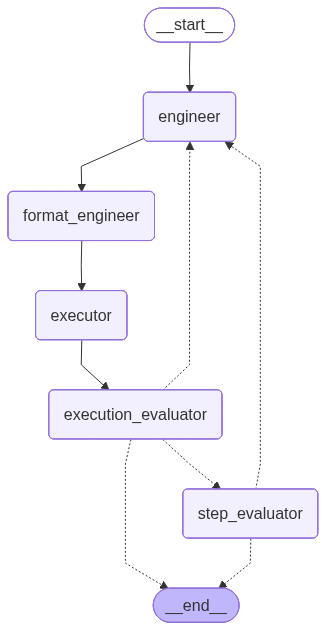

In [1]:
from cmbagent_lg import self_debug_graph
from IPython.display import Image, display

try:
    display(Image(self_debug_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(self_debug_graph.get_graph().draw_ascii())

## 3. Why *two* verdicts?

This is the core design idea of Lab 5. cmbagent splits the judgment in two, and so do we:

| | `ExecutionVerdict` | `StepVerdict` |
| --- | --- | --- |
| **Question** | Did the code run without crashing? | Did the run achieve the sub-task's goal? |
| **Node** | `execution_evaluator` | `step_evaluator` |
| **Fields** | `status`, `error_summary`, `fix_suggestion` | `fulfilled`, `unmet_requirements`, `feedback` |
| **Fails when** | traceback, non-zero exit code, timeout | a bullet point unmet, an expected file missing, the goal not met |
| **Saved to** | `logs/step_N_execution_verdict.json` | `logs/step_N_verdict.json` |

**Why not one verdict?** Because *code that runs cleanly can still miss the point.* A script asked to "save the data as CSV **and** plot it" might run perfectly, exit 0 — and only produce the plot. Gate 1 (`execution_evaluator`) is happy: no traceback. Gate 2 (`step_evaluator`) catches it: a bullet point went unmet.

`step_evaluator` judges from the script's **stdout** and the **list of files it produced** (paths and sizes — not contents, for now). It catches *gross* misses: a skipped requirement, a missing file, an error the script caught and swallowed. It can't yet judge whether a plot is *correct* — that's a future extension.

## 4. Run it — one `Step` in, working code out

`self_debug_graph` is invoked just like the planner graph from Lab 4: pass the initial state and a `PlanContext`. The state carries the `Step`; the context carries the knobs (`max_n_attempts`, `code_execution_timeout`, …).

We start with a task that should succeed on the first attempt.

In [ ]:
from cmbagent_lg import PlanContext, Step, prepare_work_dir

ctx = PlanContext(
    improved_main_task='Print the first 10 prime numbers and their sum.',
    code_execution_timeout=30,
    max_n_attempts=3,
)

step = Step(
    sub_task='Compute the first 10 prime numbers, print them, then print their sum.',
    sub_task_agent='engineer',
    bullet_points=[
        'Use a simple trial-division primality test.',
        'Print each prime on its own line.',
        'After the list, print a line of the form sum=<value>.',
    ],
    code_execution_timeout=30,
)

# prepare_work_dir clears any previous run at this path, so reruns start clean.
work_dir = prepare_work_dir('work_dir/lab5_primes')

result = self_debug_graph.invoke(
    {'step': step, 'work_dir': str(work_dir), 'step_number': 1},
    context=ctx,
    config={'callbacks': callbacks},
)

print(f'attempts:           {result["attempts"]} / {ctx.max_n_attempts}')
print(f'execution verdict:  {result["current_execution_verdict"].status}')
print(f'step verdict:       fulfilled={result["current_step_verdict"].fulfilled}')

The graph returns the final state. `current_code` is the typed `EngineerResponse` — let's read the script it actually wrote and ran:

In [ ]:
print(result['current_code'].python_code)

And here are the two verdicts in full. On a clean run, both pass and the optional fields stay `None`:

In [ ]:
print('=== EXECUTION VERDICT (did the code run?) ===')
print(result['current_execution_verdict'].format())
print('=== STEP VERDICT (did it achieve the goal?) ===')
print(result['current_step_verdict'].format())

## 5. What lands on disk

`self_debug` writes a small, predictable tree under `work_dir`, modelled on cmbagent's `codebase/` + `data/` layout:

```
work_dir/lab5_primes/
├── codebase/
│   ├── step_1.py    ← the working script (canonical name)
│   └── step_1.log   ← its stdout + stderr + returncode
├── data/            ← output files the script produced (empty here)
└── logs/
    ├── step_1_execution_verdict.json   ← Gate 1 result
    ├── step_1_verdict.json             ← Gate 2 result
    ├── step_1_data_manifest.json       ← which data/ files this step made
    └── step_1_timings.json             ← per-node wall-clock
```

Two details worth knowing:

- **Failure audit trail.** If an attempt's code fails, `execution_evaluator` renames `step_1.py` → `step_1_failure_1.py` (and its `.log` too). The canonical name is freed for the next attempt, and every failed attempt stays on disk to inspect.
- **Every node is timed.** `result['node_elapsed_s']` is a list of `{node, elapsed_s}` — wall-clock for each node pass, also written to `logs/step_N_timings.json`.

In [ ]:
import subprocess
print(subprocess.run(['find', str(work_dir), '-type', 'f'],
                     capture_output=True, text=True).stdout)

print('--- per-node wall-clock ---')
for t in result['node_elapsed_s']:
    print(f'  {t["node"]:<20s} {t["elapsed_s"]:6.2f}s')

## 6. The retry loop — recovering from a failure

The whole point of `self_debug` is what happens when code *breaks*. To trigger it on purpose we give the engineer an instruction that doesn't work in modern SciPy: `from scipy.signal import gaussian` was removed in SciPy 1.13 (it moved to `scipy.signal.windows`).

Attempt 1 should fail with an `ImportError`. The `execution_evaluator` catches it, writes an `error_summary` + `fix_suggestion`, and the router sends it back to the **engineer** — which now sees the failure in its prompt and adapts.

In [ ]:
retry_ctx = PlanContext(
    improved_main_task='Smooth a noisy 1D signal with a Gaussian window from SciPy.',
    code_execution_timeout=30,
    max_n_attempts=3,
)

retry_step = Step(
    sub_task='Smooth a noisy 1D signal using a Gaussian window from SciPy.',
    sub_task_agent='engineer',
    bullet_points=[
        'Generate a 1000-sample noisy sine wave with NumPy (add Gaussian noise, seed 0).',
        'Build the smoothing kernel by importing gaussian directly from scipy.signal '
        'with: from scipy.signal import gaussian',
        'Do NOT use scipy.signal.windows — a downstream check requires the import to be '
        'exactly from scipy.signal import gaussian.',
        'Normalize the kernel to sum to 1, convolve it with the signal, and print the '
        'first 5 smoothed values.',
    ],
    code_execution_timeout=30,
)

retry_dir = prepare_work_dir('work_dir/lab5_retry')

retry_result = self_debug_graph.invoke(
    {'step': retry_step, 'work_dir': str(retry_dir), 'step_number': 1},
    context=retry_ctx,
    config={'callbacks': callbacks},
)

print(f'attempts:      {retry_result["attempts"]} / {retry_ctx.max_n_attempts}')
print(f'step verdict:  fulfilled={retry_result["current_step_verdict"].fulfilled}')
print()
print('error_history (one entry per failed attempt):')
for i, err in enumerate(retry_result['error_history'], start=1):
    print(f'  attempt {i}: {err}')

`attempts` is **2** (or 3): the loop failed at least once and recovered. Two mechanisms make that work:

- **`error_history`** accumulates one summary per failed attempt. Every subsequent engineer pass sees the *whole* trail — so it won't re-try a fix that already failed.
- **The retry context** injected into the engineer's prompt is mode-aware: a *code-error* retry shows the traceback + `fix_suggestion`; a *goal-miss* retry (Gate 2) shows the unmet requirements + reviewer `feedback`. The engineer picks the mode from the last verdict, so a stale message never leaks.

The failed attempt is preserved on disk as `codebase/step_1_failure_1.py` next to the working `step_1.py`:

In [ ]:
print(subprocess.run(['ls', '-1', str(retry_dir / 'codebase')],
                     capture_output=True, text=True).stdout)

## 7. Output files and the data manifest

Steps usually *produce* something — a plot, a CSV, a `.npy` array. By convention (cmbagent's `database_path`) the engineer writes these into a `data/` directory, and the `executor` runs the script with `cwd = work_dir` so the relative path `data/<file>` lands in `work_dir/data/`.

That raises a provenance question: **once step 1 has run, how do we know which `data/` files it produced?** We don't want to (a) make the LLM write a step id into its code, or (b) rename the files. So the `executor` records it externally: it snapshots `data/` before the step, diffs afterwards, and writes a **manifest** — `logs/step_N_data_manifest.json` — listing exactly the files that step created. The files themselves are never touched.

In [ ]:
manifest_ctx = PlanContext(
    improved_main_task='Generate a damped oscillation, save it as CSV, and plot it.',
    code_execution_timeout=60,
    max_n_attempts=3,
)

manifest_step = Step(
    sub_task='Generate a damped oscillation, save it as CSV, and plot it.',
    sub_task_agent='engineer',
    bullet_points=[
        'Compute a damped sine wave on 400 evenly spaced points.',
        'Save the dataset as CSV at data/damped_oscillation.csv with a header row.',
        'Plot the wave with matplotlib and save it to data/damped_oscillation.png.',
        'Print the path of each file saved.',
    ],
    code_execution_timeout=60,
)

manifest_dir = prepare_work_dir('work_dir/lab5_csv_plot')

manifest_result = self_debug_graph.invoke(
    {'step': manifest_step, 'work_dir': str(manifest_dir), 'step_number': 1},
    context=manifest_ctx,
    config={'callbacks': callbacks},
)

print(f'step fulfilled: {manifest_result["current_step_verdict"].fulfilled}')
print()
print('data manifest — files attributed to step 1:')
for f in manifest_result['data_manifest']:
    print(f'  {f["path"]:<32s} {f["bytes"]:>9d} bytes')

The manifest is also what `step_evaluator` reads to check file-producing requirements — it sees *"step 1 produced `data/damped_oscillation.csv` and `data/damped_oscillation.png`"* and can confirm both bullet points were met. Let's look at the plot:

In [ ]:
png = manifest_dir / 'data' / 'damped_oscillation.png'
display(Image(str(png))) if png.exists() else print('no plot produced')

## 8. Tracing — unchanged from Lab 4

The Langfuse wiring from Lab 4 carries over with **zero changes**: the same `langfuse_handler()` passed in `config={'callbacks': [...]}`. Every LLM call in the loop — `engineer`, `format_engineer`, `execution_evaluator`, `step_evaluator` — is tagged with its node name, so the `cmbagent-lg-cost` CLI breaks the run down per agent.

(`executor` never appears — it runs a subprocess, not an LLM call.)

In [ ]:
import sys, time, subprocess
from langfuse import get_client

if handler is not None and handler.last_trace_id:
    trace_id = handler.last_trace_id
    print(f'latest trace: http://localhost:3000/trace/{trace_id}')
    # Langfuse ingests traces asynchronously — flush the SDK buffer and
    # give the server a moment, so the cost query sees the whole trace.
    get_client().flush()
    time.sleep(3)
    # `python -m cmbagent_lg.cli cost` is the `cmbagent-lg-cost` console
    # script — invoked this way it works regardless of PATH.
    out = subprocess.run(
        [sys.executable, '-m', 'cmbagent_lg.cli', 'cost', trace_id],
        capture_output=True, text=True,
    )
    print(out.stdout or out.stderr)
else:
    print('Langfuse not attached — skip this section, or set LANGFUSE_* in .env and rerun.')

## 9. Recap

**Concepts**

- `self_debug` is `cmbagent_lg`'s second module: **one `Step` in → working, executed code out**, or an honest failure after `max_n_attempts`.
- The loop is **engineer → format_engineer → executor → execution_evaluator → step_evaluator**, with **two gates**: did the code *run*, and did it *achieve the goal*. Code can pass the first and fail the second.
- Retries are driven by feedback: `error_history` (the cumulative failure trail) plus a mode-aware retry context (traceback vs. unmet requirements) injected into the engineer's prompt.
- Artifacts land in a predictable tree — `codebase/` (scripts + failure variants), `data/` (outputs), `logs/` (both verdicts, the data manifest, timings).
- The **data manifest** records step→file provenance externally, without renaming files or touching the LLM's code.

**Code**

- `from cmbagent_lg import self_debug_graph, PlanContext, Step` — the whole API.
- `self_debug_graph.invoke({'step': step, 'work_dir': ..., 'step_number': 1}, context=ctx, config={'callbacks': callbacks})`.
- Read the result: `current_code`, `current_execution_verdict`, `current_step_verdict`, `attempts`, `error_history`, `data_manifest`, `node_elapsed_s`.

**Where this is going**

- A **`deep_research`** module that runs the planner (Lab 4), then feeds each `Step` of the resulting plan through `self_debug` (Lab 5) in turn — the first step writing `codebase/step_1.py`, the next able to `from step_1 import …`.
- A richer `step_evaluator` that inspects file *contents* (CSV columns, array shapes) and, eventually, plot correctness via a vision model.
- Specialist routing (an `installer` for missing packages, library-context agents) on the failure path.